# AAOI Financial Scenario & Sensitivity Modeling

This notebook analyzes historical AAOI financial performance and projects 2026 revenue, gross profit, and break-even outcomes under downside, base, and upside scenarios.

The analysis also includes sensitivity testing across revenue growth and gross margin assumptions.

## Data

The model uses historical AAOI financial data, including:
- Revenue
- Gross margin
- Net income

All values are expressed in USD millions.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("../data/aaoi_financials.csv")

df

,year,revenue,gross_margin,net_income
0,2023,222.9,21.8,-160.4
1,2024,249.4,24.8,-186.7
2,2025,455.7,30.1,-38.2


In [26]:
df["gross_profit"] = df["revenue"] * df["gross_margin"] / 100
df["cost"] = df["revenue"] - df["gross_profit"]

df

,year,revenue,gross_margin,net_income,gross_profit,cost
0,2023,222.9,21.8,-160.4,48.5922,174.3078
1,2024,249.4,24.8,-186.7,61.8512,187.5488
2,2025,455.7,30.1,-38.2,137.1657,318.5343


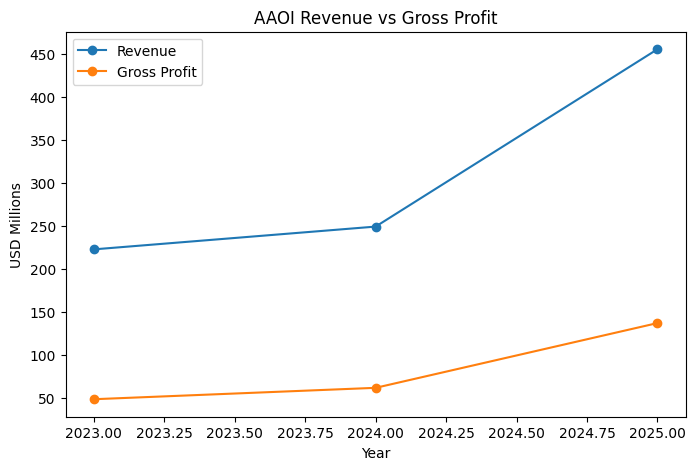

In [27]:
plt.figure(figsize=(8,5))

plt.plot(df["year"], df["revenue"], marker="o", label="Revenue")
plt.plot(df["year"], df["gross_profit"], marker="o", label="Gross Profit")

plt.title("AAOI Revenue vs Gross Profit")
plt.xlabel("Year")
plt.ylabel("USD Millions")
plt.legend()

plt.show()

## 2026 Scenario Projection

This section projects AAOI's 2026 revenue and gross profit under downside, base, and upside cases.

In [28]:
scenarios = {
    "Downside": {
        "growth": 0.05,
        "margin": 0.26
    },
    "Base": {
        "growth": 0.12,
        "margin": 0.30
    },
    "Upside": {
        "growth": 0.20,
        "margin": 0.34
    }
}

In [29]:
last_revenue = df.iloc[-1]["revenue"]

results = []

for name, s in scenarios.items():
    
    revenue = last_revenue * (1 + s["growth"])
    
    gross_profit = revenue * s["margin"]
    
    cost = revenue - gross_profit
    
    results.append({
        "scenario": name,
        "revenue": revenue,
        "gross_profit": gross_profit,
        "cost": cost,
        "margin": s["margin"]
    })

scenario_df = pd.DataFrame(results)

scenario_df

,scenario,revenue,gross_profit,cost,margin
0,Downside,478.485,124.4061,354.0789,0.26
1,Base,510.384,153.1152,357.2688,0.30
2,Upside,546.840,185.9256,360.9144,0.34


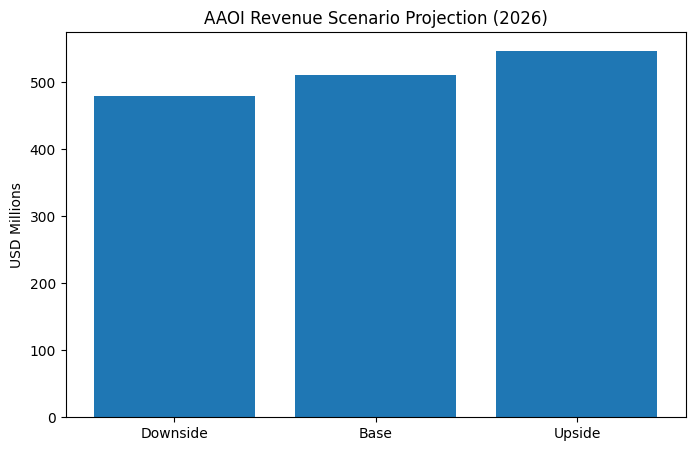

In [30]:
plt.figure(figsize=(8,5))

plt.bar(scenario_df["scenario"], scenario_df["revenue"])

plt.title("AAOI Revenue Scenario Projection (2026)")
plt.ylabel("USD Millions")

plt.show()

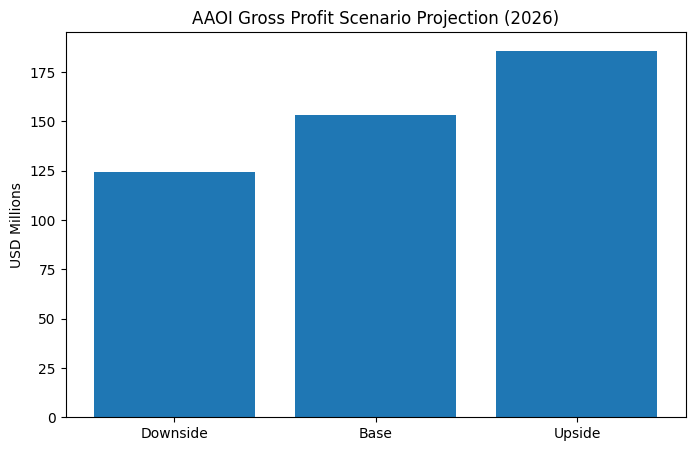

In [31]:
plt.figure(figsize=(8,5))

plt.bar(scenario_df["scenario"], scenario_df["gross_profit"])

plt.title("AAOI Gross Profit Scenario Projection (2026)")
plt.ylabel("USD Millions")

plt.show()

In [32]:
growth_range = np.arange(0.00, 0.31, 0.02)  # 0% 到 30%
base_margin = 0.30
last_revenue = df.iloc[-1]["revenue"]

growth_results = []

for g in growth_range:
    revenue = last_revenue * (1 + g)
    gross_profit = revenue * base_margin
    cost = revenue - gross_profit
    
    growth_results.append({
        "growth_rate": g,
        "revenue": revenue,
        "gross_profit": gross_profit,
        "cost": cost
    })

growth_df = pd.DataFrame(growth_results)
growth_df

,growth_rate,revenue,gross_profit,cost
0,0.00,455.700,136.7100,318.9900
1,0.02,464.814,139.4442,325.3698
2,0.04,473.928,142.1784,331.7496
3,0.06,483.042,144.9126,338.1294
4,0.08,492.156,147.6468,344.5092
5,0.10,501.270,150.3810,350.8890
6,0.12,510.384,153.1152,357.2688
7,0.14,519.498,155.8494,363.6486
8,0.16,528.612,158.5836,370.0284
9,0.18,537.726,161.3178,376.4082


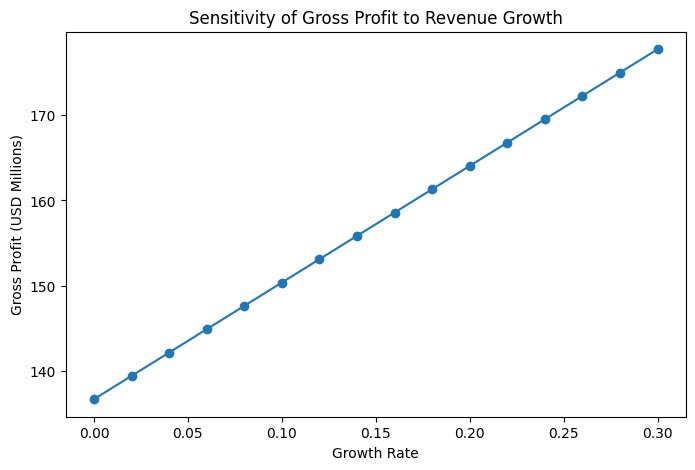

In [33]:
plt.figure(figsize=(8,5))

plt.plot(growth_df["growth_rate"], growth_df["gross_profit"], marker="o")

plt.title("Sensitivity of Gross Profit to Revenue Growth")
plt.xlabel("Growth Rate")
plt.ylabel("Gross Profit (USD Millions)")

plt.show()

In [34]:
growth_values = np.arange(0.00, 0.31, 0.05)   # 0% 到 30%
margin_values = np.arange(0.20, 0.41, 0.02)   # 20% 到 40%

heatmap_data = []

for margin in margin_values:
    row = []
    for growth in growth_values:
        revenue = last_revenue * (1 + growth)
        gross_profit = revenue * margin
        row.append(gross_profit)
    heatmap_data.append(row)

heatmap_array = np.array(heatmap_data)
heatmap_array

array([[ 91.14  ,  95.697 , 100.254 , 104.811 , 109.368 , 113.925 ,
        118.482 ],
       [100.254 , 105.2667, 110.2794, 115.2921, 120.3048, 125.3175,
        130.3302],
       [109.368 , 114.8364, 120.3048, 125.7732, 131.2416, 136.71  ,
        142.1784],
       [118.482 , 124.4061, 130.3302, 136.2543, 142.1784, 148.1025,
        154.0266],
       [127.596 , 133.9758, 140.3556, 146.7354, 153.1152, 159.495 ,
        165.8748],
       [136.71  , 143.5455, 150.381 , 157.2165, 164.052 , 170.8875,
        177.723 ],
       [145.824 , 153.1152, 160.4064, 167.6976, 174.9888, 182.28  ,
        189.5712],
       [154.938 , 162.6849, 170.4318, 178.1787, 185.9256, 193.6725,
        201.4194],
       [164.052 , 172.2546, 180.4572, 188.6598, 196.8624, 205.065 ,
        213.2676],
       [173.166 , 181.8243, 190.4826, 199.1409, 207.7992, 216.4575,
        225.1158],
       [182.28  , 191.394 , 200.508 , 209.622 , 218.736 , 227.85  ,
        236.964 ]])

## Sensitivity Analysis

This section evaluates how gross profit changes under different combinations of revenue growth and gross margin assumptions.

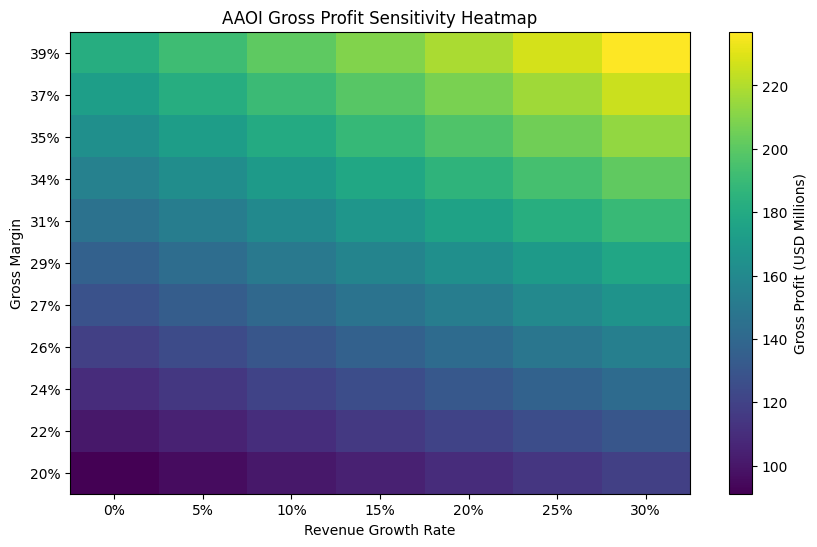

In [35]:
plt.figure(figsize=(10,6))

im = plt.imshow(heatmap_array, aspect="auto", origin="lower")
plt.colorbar(im, label="Gross Profit (USD Millions)")

plt.xticks(
    ticks=np.arange(len(growth_values)),
    labels=[f"{int(g*100)}%" for g in growth_values]
)
plt.yticks(
    ticks=np.arange(len(margin_values)),
    labels=[f"{int(m*100)}%" for m in margin_values]
)

plt.xlabel("Revenue Growth Rate")
plt.ylabel("Gross Margin")
plt.title("AAOI Gross Profit Sensitivity Heatmap")

plt.show()

In [36]:
scenario_df.to_csv("../outputs/scenario_summary.csv", index=False)
growth_df.to_csv("../outputs/growth_sensitivity.csv", index=False)

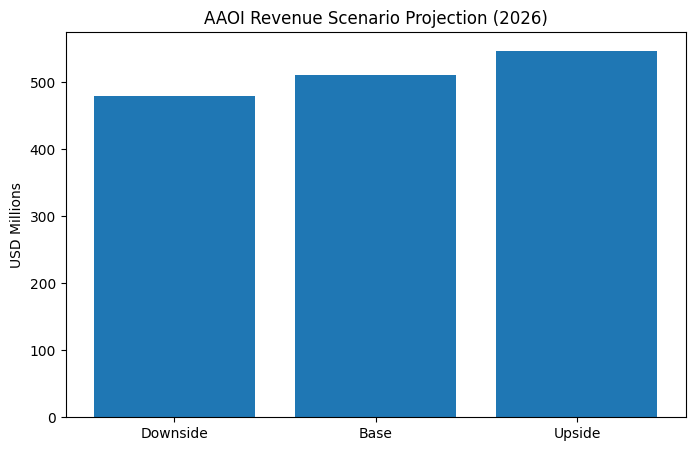

In [37]:
plt.figure(figsize=(8,5))
plt.bar(scenario_df["scenario"], scenario_df["revenue"])
plt.title("AAOI Revenue Scenario Projection (2026)")
plt.ylabel("USD Millions")
plt.savefig("../outputs/revenue_scenario.png", bbox_inches="tight")
plt.show()

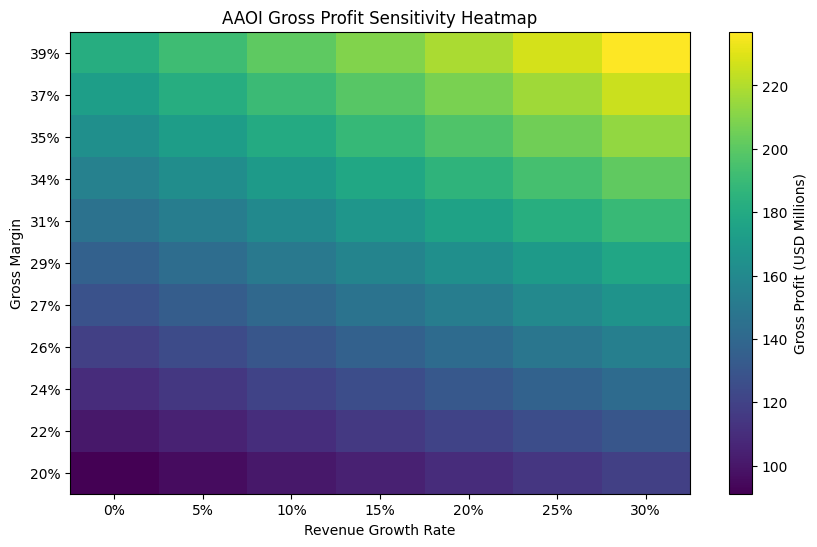

In [38]:
plt.figure(figsize=(10,6))

im = plt.imshow(heatmap_array, aspect="auto", origin="lower")
plt.colorbar(im, label="Gross Profit (USD Millions)")

plt.xticks(
    ticks=np.arange(len(growth_values)),
    labels=[f"{int(g*100)}%" for g in growth_values]
)
plt.yticks(
    ticks=np.arange(len(margin_values)),
    labels=[f"{int(m*100)}%" for m in margin_values]
)

plt.xlabel("Revenue Growth Rate")
plt.ylabel("Gross Margin")
plt.title("AAOI Gross Profit Sensitivity Heatmap")

plt.savefig("../outputs/gross_profit_heatmap.png", bbox_inches="tight")
plt.show()

## Break-even Analysis

This section estimates the revenue required to cover the fixed cost pool under different gross margin assumptions.

In [39]:
df["fixed_cost_pool"] = df["gross_profit"] - df["net_income"]

df[["year", "revenue", "gross_profit", "net_income", "fixed_cost_pool"]]

,year,revenue,gross_profit,net_income,fixed_cost_pool
0,2023,222.9,48.5922,-160.4,208.9922
1,2024,249.4,61.8512,-186.7,248.5512
2,2025,455.7,137.1657,-38.2,175.3657


In [40]:
base_fixed_cost = df.iloc[-1]["fixed_cost_pool"]
base_fixed_cost

np.float64(175.3657)

In [41]:
scenario_df["break_even_revenue"] = base_fixed_cost / scenario_df["margin"]

scenario_df

,scenario,revenue,gross_profit,cost,margin,break_even_revenue
0,Downside,478.485,124.4061,354.0789,0.26,674.483462
1,Base,510.384,153.1152,357.2688,0.30,584.552333
2,Upside,546.840,185.9256,360.9144,0.34,515.781471


In [42]:
scenario_df["break_even_gap"] = scenario_df["revenue"] - scenario_df["break_even_revenue"]

scenario_df

,scenario,revenue,gross_profit,cost,margin,break_even_revenue,break_even_gap
0,Downside,478.485,124.4061,354.0789,0.26,674.483462,-195.998462
1,Base,510.384,153.1152,357.2688,0.30,584.552333,-74.168333
2,Upside,546.840,185.9256,360.9144,0.34,515.781471,31.058529


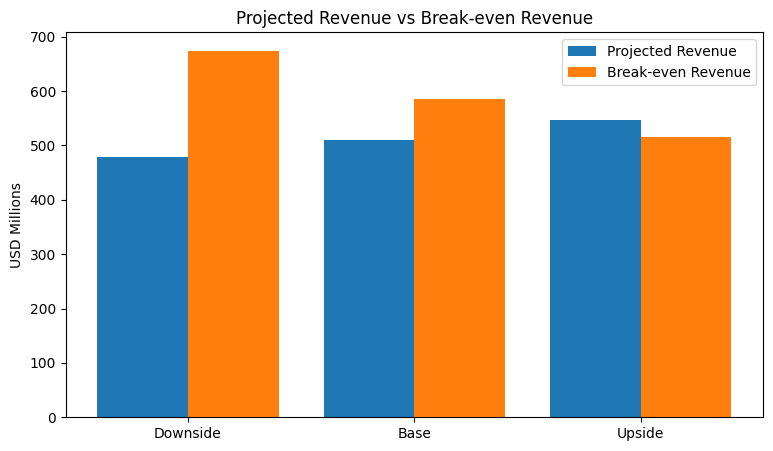

In [43]:
x = np.arange(len(scenario_df))

plt.figure(figsize=(9,5))

plt.bar(x - 0.2, scenario_df["revenue"], width=0.4, label="Projected Revenue")
plt.bar(x + 0.2, scenario_df["break_even_revenue"], width=0.4, label="Break-even Revenue")

plt.xticks(x, scenario_df["scenario"])
plt.ylabel("USD Millions")
plt.title("Projected Revenue vs Break-even Revenue")
plt.legend()

plt.show()

In [44]:
scenario_df.to_csv("../outputs/scenario_summary_with_breakeven.csv", index=False)

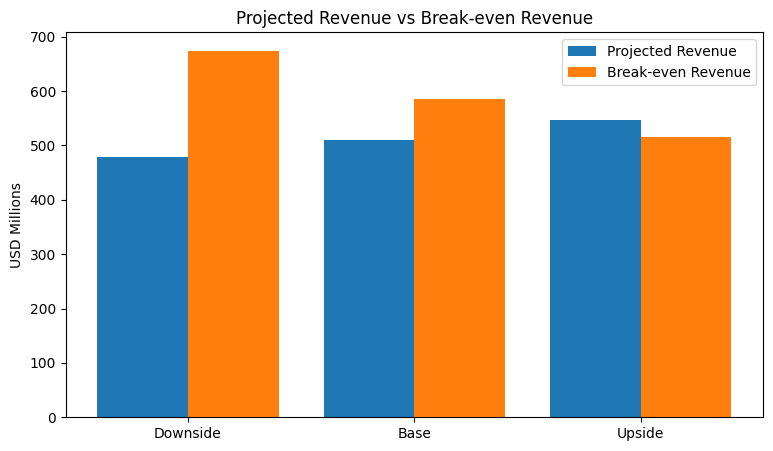

In [45]:
x = np.arange(len(scenario_df))

plt.figure(figsize=(9,5))

plt.bar(x - 0.2, scenario_df["revenue"], width=0.4, label="Projected Revenue")
plt.bar(x + 0.2, scenario_df["break_even_revenue"], width=0.4, label="Break-even Revenue")

plt.xticks(x, scenario_df["scenario"])
plt.ylabel("USD Millions")
plt.title("Projected Revenue vs Break-even Revenue")
plt.legend()

plt.savefig("../outputs/break_even_analysis.png", bbox_inches="tight")
plt.show()